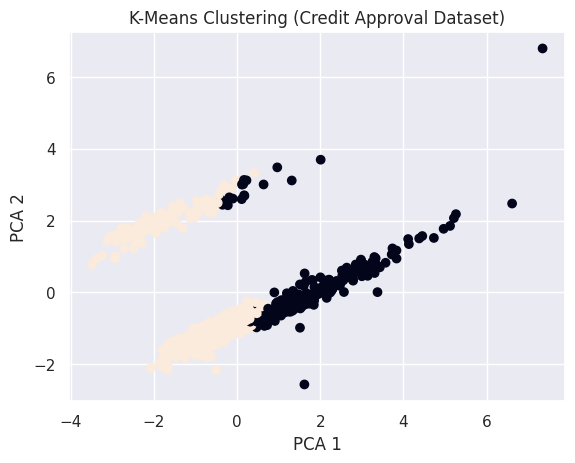

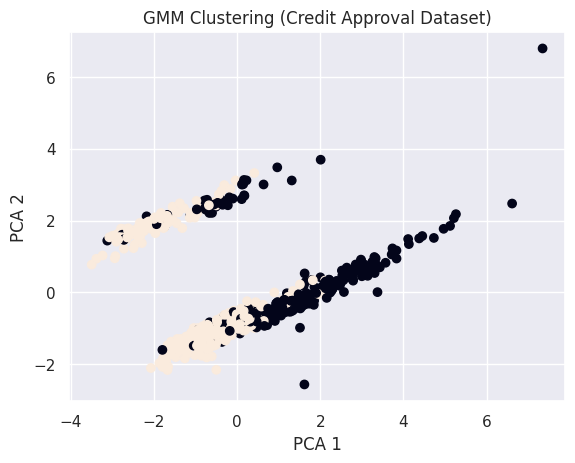

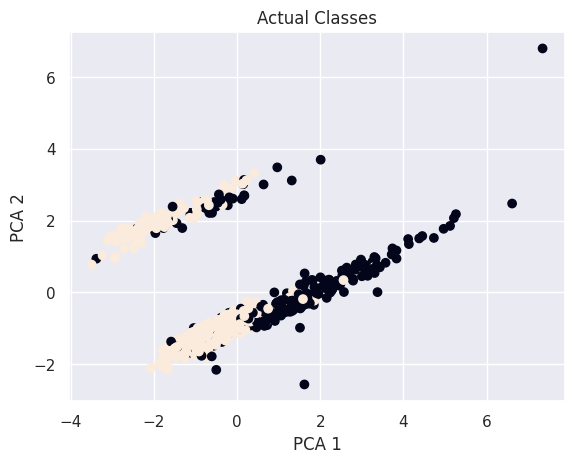

In [1]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set()

# ================================
# LOAD DATASET (CREDIT APPROVAL)
# ================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"

# Column names (as per dataset description)
columns = [f"A{i}" for i in range(1, 17)]
df = pd.read_csv(url, header=None, names=columns)

# ================================
# DATA PREPROCESSING
# ================================

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop rows with missing values
df.dropna(inplace=True)

# Separate target column (A16)
target = df['A16']
df = df.drop(columns=['A16'])

# Encode categorical columns
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Encode target (optional)
target = LabelEncoder().fit_transform(target)

# ================================
# FEATURE SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ================================
# K-MEANS CLUSTERING
# ================================
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# ================================
# GMM CLUSTERING
# ================================
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# ================================
# PCA FOR VISUALIZATION
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ================================
# VISUALIZATION
# ================================

# KMeans Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering (Credit Approval Dataset)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# GMM Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels)
plt.title("GMM Clustering (Credit Approval Dataset)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# ================================
# OPTIONAL: COMPARE WITH TRUE LABELS
# ================================
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target)
plt.title("Actual Classes")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

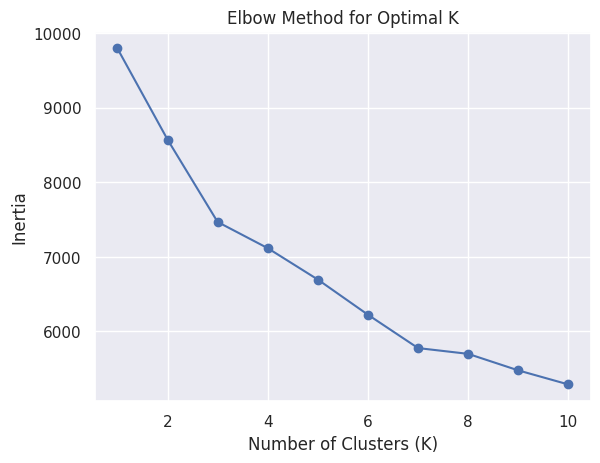

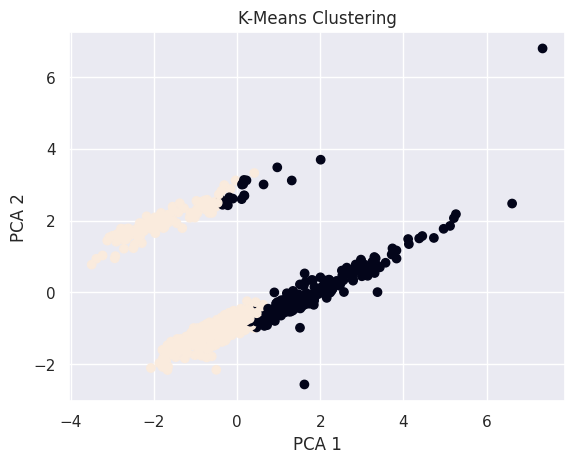

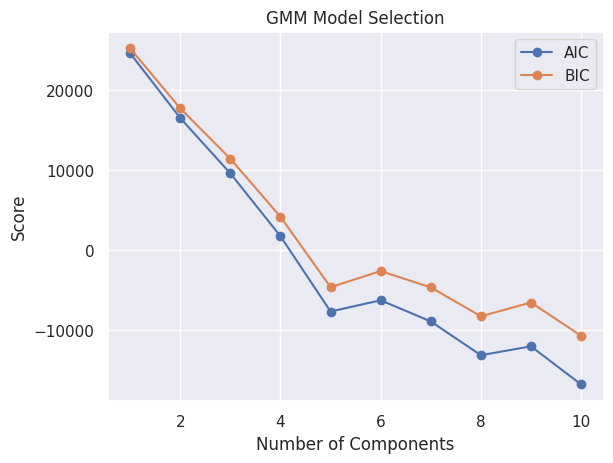

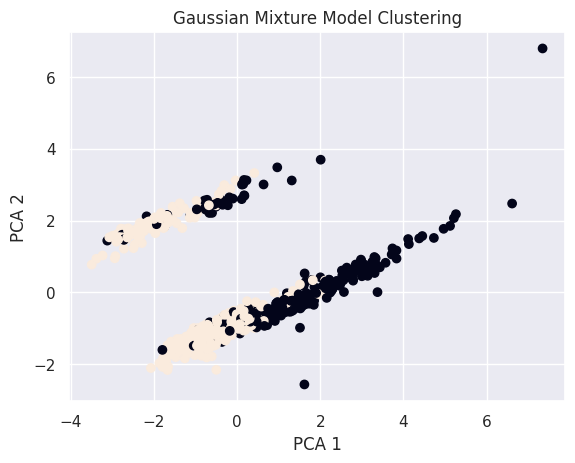

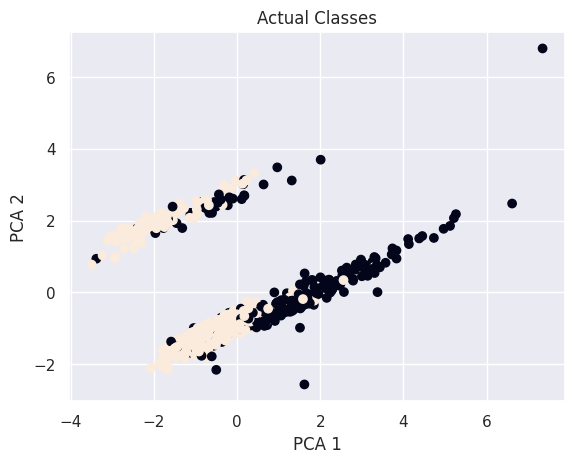

In [2]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set()

# ================================
# LOAD DATASET
# ================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
columns = [f"A{i}" for i in range(1, 17)]
df = pd.read_csv(url, header=None, names=columns)

# ================================
# PREPROCESSING
# ================================

# Replace missing values
df.replace('?', np.nan, inplace=True)

# Drop missing rows
df.dropna(inplace=True)

# Separate target
target = df['A16']
df = df.drop(columns=['A16'])

# Encode categorical features
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Encode target (optional)
target = LabelEncoder().fit_transform(target)

# ================================
# FEATURE SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ================================
# PCA (FOR VISUALIZATION)
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ================================
# 🔵 K-MEANS ELBOW METHOD
# ================================
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# ================================
# 🔵 FINAL K-MEANS
# ================================
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# ================================
# 🟢 GMM AIC & BIC GRAPH
# ================================
aic = []
bic = []
n_components_range = range(1, 11)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(n_components_range, aic, marker='o', label='AIC')
plt.plot(n_components_range, bic, marker='o', label='BIC')
plt.title("GMM Model Selection")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.show()

# ================================
# 🟢 FINAL GMM
# ================================
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels)
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# ================================
# 🔴 ACTUAL LABEL COMPARISON
# ================================
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target)
plt.title("Actual Classes")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()